In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm 

import torch
from torch import nn
import torchvision
import torchvision.transforms as transforms

import numpy as np
import random
np.random.seed(0)
torch.manual_seed(0)
random.seed(0)


# Data

In [2]:

transform = transforms.ToTensor()

training_set = torchvision.datasets.FashionMNIST('./data', train=True, transform=transform, download=True)
validation_set = torchvision.datasets.FashionMNIST('./data', train=False, transform=transform, download=True)

training_loader = torch.utils.data.DataLoader(training_set, batch_size=32, shuffle=True)
validation_loader = torch.utils.data.DataLoader(validation_set, batch_size=128, shuffle=False)

classes = ('T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
        'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle Boot')


100%|██████████| 26.4M/26.4M [00:07<00:00, 3.60MB/s]


Extracting ./data\FashionMNIST\raw\train-images-idx3-ubyte.gz to ./data\FashionMNIST\raw



100%|██████████| 29.5k/29.5k [00:00<00:00, 441kB/s]


Extracting ./data\FashionMNIST\raw\train-labels-idx1-ubyte.gz to ./data\FashionMNIST\raw



100%|██████████| 4.42M/4.42M [00:02<00:00, 1.82MB/s]


Extracting ./data\FashionMNIST\raw\t10k-images-idx3-ubyte.gz to ./data\FashionMNIST\raw



100%|██████████| 5.15k/5.15k [00:00<?, ?B/s]

Extracting ./data\FashionMNIST\raw\t10k-labels-idx1-ubyte.gz to ./data\FashionMNIST\raw



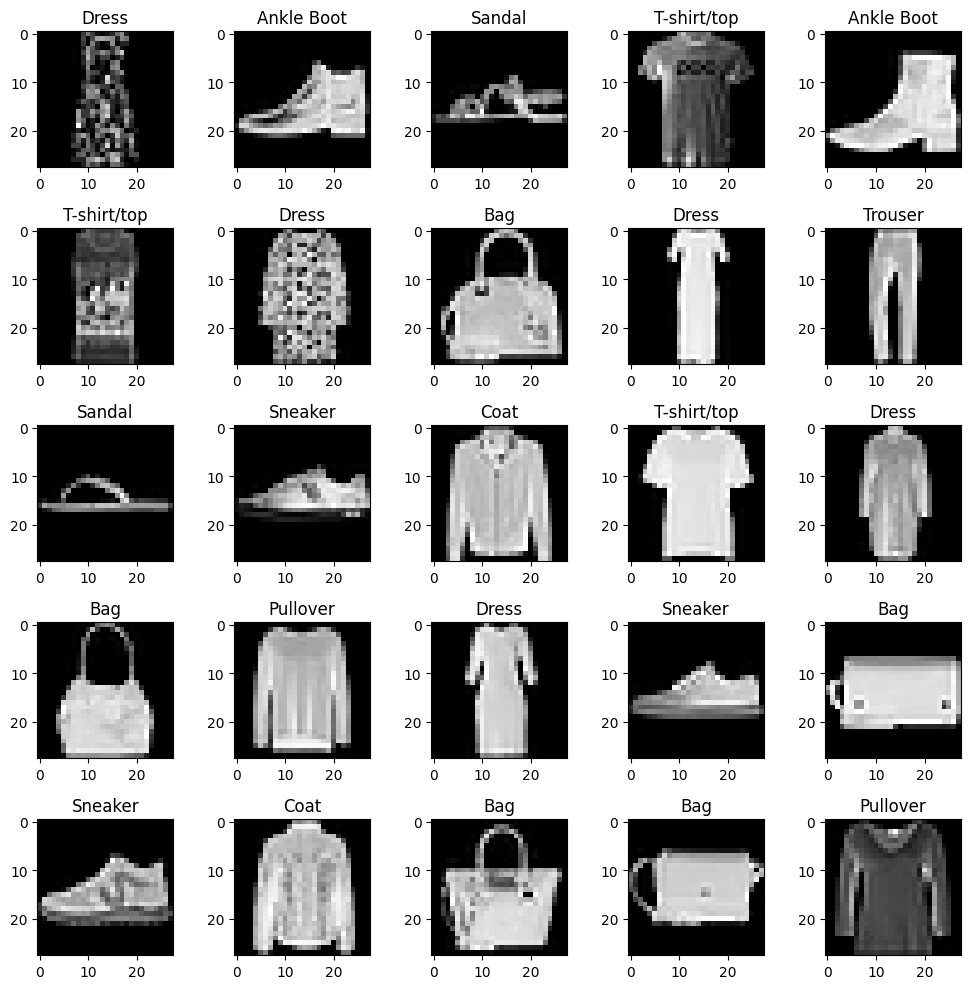

In [3]:
batch = next(iter(training_loader))
plt.figure(figsize=(10, 10))
for i, (image, label) in enumerate(zip(*batch)):
    if i > 24:
        break
    plt.subplot(5, 5, i + 1)
    plt.imshow(image[0], cmap="gray")
    plt.title(classes[label])

plt.tight_layout()

# Exercise

You are required to train an MLP on the Fashion MNIST dataset. For this task, you must define the following:

* The objective function
* The model architecture
* The optimizer
* The training loop

You will train three MLP models, each with different hyperparameters. You must vary at least two of the following aspects between the models:

* Number of layers
* Number of neurons
* Activation function
* Optimizer


## Deliverables
* The complete code
* Learning curves for the three MLP models
* Table summarizing the changes in the hyperparameters and the performance of the models on the train and test sets. 
* A write-up analyzing how your choices impacted the results.

In [4]:
training_set[0][0].shape

torch.Size([1, 28, 28])

In [12]:
validation_loader.batch_size

128

In [15]:
class NN1(nn.Module):
    def __init__(self, activation, input_size=28*28, output_size=10):
        super(NN1, self).__init__()
        self.activation = activation
        self.l1 = nn.Linear(input_size, 64)
        self.l2 = nn.Linear(64, 128)
        self.l3 = nn.Linear(128, 256)
        self.l4 = nn.Linear(256,64)
        self.l5 = nn.Linear(64, output_size)
    def forward(self, x):
        x = self.activation(self.l1(x))
        x = self.activation(self.l2(x))
        x = self.activation(self.l3(x))
        x = self.activation(self.l4(x))
        x = self.l5(x)
        return x

In [47]:
def train(model, optimizer):
    criterion = nn.CrossEntropyLoss()
    epochs = 10
    epoch_losses = []
    for epoch in range(epochs):
        model.train()
        correct = 0
        total = 0
        Acc = []
        batch_losses = []
        for images, labels in training_loader:
            optimizer.zero_grad()
            images = images.view(-1, 28*28)
            output = model(images)
            loss = criterion(output, labels)
            loss.backward()
            optimizer.step()
            batch_losses.append(loss.item())
            predicted = torch.argmax(output, dim=1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            Acc.append(100 * correct / total)
        epoch_losses.append(np.mean(batch_losses))
        print(f"Epoch {epoch+1}/{epochs}, Loss: {np.mean(batch_losses)}, Accuracy: {100 * correct / total}")
    return epoch_losses, Acc

def eval(model):
    model.eval()
    right_preds = 0
    total_preds = 0
    with torch.no_grad():
        for images, labels in validation_loader:
            images = images.view(-1, 28*28)
            output = model(images)
            predicted = torch.argmax(output, dim=1)
            total_preds += labels.size(0)
            right_preds += (predicted == labels).sum().item()
    return 100 * (right_preds / total_preds)          

In [48]:
model1 = NN1(nn.ELU())
model2 = NN1(nn.SiLU())
model3 = NN1(nn.GELU())
optimizer1= torch.optim.Adam(model1.parameters(), lr=1e-3)
optimizer2= torch.optim.SGD(model2.parameters(), lr=1e-3)
optimizer3= torch.optim.RMSprop(model3.parameters(), lr=1e-3)

In [49]:
losses1, train1_acc = train(model1, optimizer1)
valid1_acc = eval(model1)

Epoch 1/10, Loss: 0.5162472176591555, Accuracy: 81.01833333333333
Epoch 2/10, Loss: 0.39098265423377354, Accuracy: 85.72833333333334
Epoch 3/10, Loss: 0.35521464105844497, Accuracy: 86.88
Epoch 4/10, Loss: 0.3350189917842547, Accuracy: 87.53666666666666
Epoch 5/10, Loss: 0.31734774867097537, Accuracy: 88.16833333333334
Epoch 6/10, Loss: 0.30134026033878325, Accuracy: 88.78833333333333
Epoch 7/10, Loss: 0.2886234662652016, Accuracy: 89.33
Epoch 8/10, Loss: 0.2767655314236879, Accuracy: 89.705
Epoch 9/10, Loss: 0.26831384627223015, Accuracy: 89.86666666666666
Epoch 10/10, Loss: 0.2563862306897839, Accuracy: 90.36666666666666


In [50]:
losses2, train2_acc = train(model2, optimizer2)
valid2_acc = eval(model2)

Epoch 1/10, Loss: 2.3049717179616294, Accuracy: 10.0
Epoch 2/10, Loss: 2.3035751499176027, Accuracy: 10.0
Epoch 3/10, Loss: 2.3024712151845295, Accuracy: 10.0
Epoch 4/10, Loss: 2.3015128209431968, Accuracy: 10.0
Epoch 5/10, Loss: 2.3005753871917727, Accuracy: 10.14
Epoch 6/10, Loss: 2.299539375813802, Accuracy: 15.231666666666667
Epoch 7/10, Loss: 2.298255187479655, Accuracy: 24.283333333333335
Epoch 8/10, Loss: 2.2964921362559, Accuracy: 30.39666666666667
Epoch 9/10, Loss: 2.2938103649139405, Accuracy: 30.86
Epoch 10/10, Loss: 2.2892228335062663, Accuracy: 25.496666666666666


In [51]:
losses3, train3_acc = train(model3, optimizer3)
valid3_acc = eval(model3)

Epoch 1/10, Loss: 0.5282173236966133, Accuracy: 80.00833333333334
Epoch 2/10, Loss: 0.3836019146104654, Accuracy: 85.68666666666667
Epoch 3/10, Loss: 0.34536241760253905, Accuracy: 87.17166666666667
Epoch 4/10, Loss: 0.31917016108234725, Accuracy: 88.055
Epoch 5/10, Loss: 0.29778351689080396, Accuracy: 88.99666666666667
Epoch 6/10, Loss: 0.28332070011496546, Accuracy: 89.38833333333334
Epoch 7/10, Loss: 0.27128971086740494, Accuracy: 89.81666666666666
Epoch 8/10, Loss: 0.26001596414248146, Accuracy: 90.08666666666667
Epoch 9/10, Loss: 0.24861231454660496, Accuracy: 90.45166666666667
Epoch 10/10, Loss: 0.23975439735750356, Accuracy: 90.96666666666667


In [52]:
print(f"trainAcc: {train1_acc[-1]}, ValidAcc: {valid1_acc}")
print(f"trainAcc: {train2_acc[-1]}, ValidAcc: {valid2_acc}")
print(f"trainAcc: {train3_acc[-1]}, ValidAcc: {valid3_acc}")

trainAcc: 90.36666666666666, ValidAcc: 88.42999999999999
trainAcc: 25.496666666666666, ValidAcc: 24.610000000000003
trainAcc: 90.96666666666667, ValidAcc: 87.45


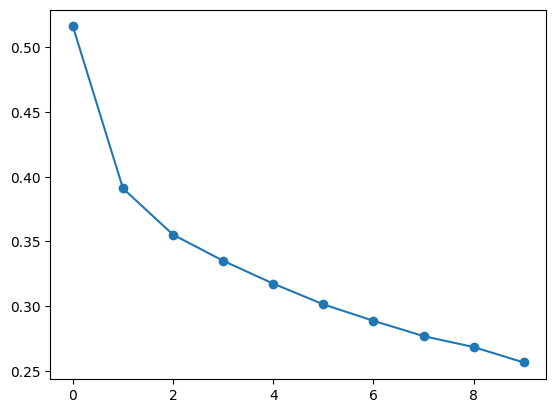

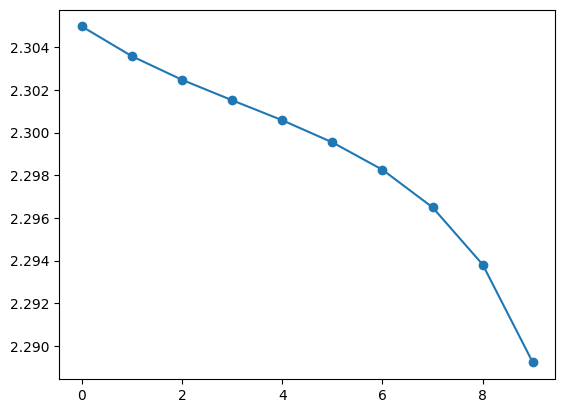

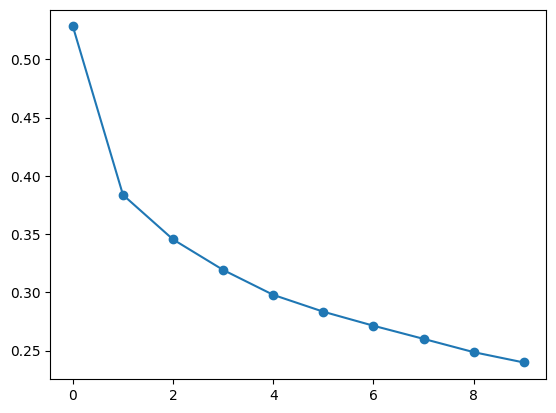

In [53]:
import matplotlib.pyplot as plt
plt.plot(losses1, label="model1 loss", marker='o')
plt.show()
plt.plot(losses2, label="model2 loss", marker='o')
plt.show()
plt.plot(losses3, label="model3 loss", marker='o')
plt.show()

In [44]:
model1.state_dict()

OrderedDict([('l1.weight',
              tensor([[ 0.2011, -0.0735, -0.2904,  ..., -0.0171, -0.3832, -0.0988],
                      [ 0.0810, -0.0074, -0.2634,  ..., -0.3539, -0.0306,  0.0536],
                      [-0.1024,  0.0774,  0.0884,  ...,  0.2273,  0.1557,  0.1520],
                      ...,
                      [ 0.0370,  0.1217,  0.1420,  ...,  0.3365,  0.1247,  0.1047],
                      [-0.2879, -0.2515, -0.2852,  ..., -0.5237, -0.3256, -0.5182],
                      [-0.2929, -0.2626, -0.4308,  ..., -0.0710,  0.2703, -0.3635]])),
             ('l1.bias',
              tensor([ 0.0617,  0.0275,  0.2489,  0.0720,  0.0084, -0.4318,  0.1298,  0.1008,
                      -0.0838,  0.0507, -0.0989,  0.1240,  0.0509, -0.2055,  0.0855, -0.1465,
                       0.0025, -0.0086,  0.0449, -0.1740, -0.1220, -0.1558, -0.1381, -0.3389,
                      -0.0154, -0.1832,  0.0150,  0.1083, -0.1077,  0.2440, -0.1404,  0.1062,
                       0.0268, -0.3081

In [45]:
model2.state_dict()

OrderedDict([('l1.weight',
              tensor([[ 0.0109,  0.0017,  0.0306,  ...,  0.0029,  0.0118, -0.0085],
                      [ 0.0320,  0.0156,  0.0247,  ...,  0.0030, -0.0171,  0.0182],
                      [ 0.0186, -0.0265,  0.0006,  ...,  0.0292, -0.0069,  0.0077],
                      ...,
                      [-0.0348, -0.0099, -0.0283,  ...,  0.0081, -0.0053, -0.0094],
                      [ 0.0154,  0.0281, -0.0084,  ..., -0.0073,  0.0063,  0.0240],
                      [ 0.0310,  0.0238,  0.0202,  ...,  0.0347, -0.0327, -0.0238]])),
             ('l1.bias',
              tensor([-3.1915e-04,  1.6594e-02,  2.4714e-02, -3.2074e-02,  2.5826e-02,
                       1.1464e-02,  3.3539e-04, -8.6978e-03,  2.3128e-02,  2.7839e-03,
                       8.5081e-03, -4.4586e-03,  2.9581e-02,  3.5187e-02,  2.2632e-02,
                       5.2421e-03,  1.7101e-02, -2.8942e-02, -2.0851e-02,  1.0189e-03,
                      -3.2993e-02, -1.4978e-02, -9.0398e-03, -2.68

In [46]:
model3.state_dict()

OrderedDict([('l1.weight',
              tensor([[ 1.2572e-01,  1.1831e-01, -1.9096e-01,  ...,  1.2483e-01,
                        1.0922e-01,  3.0477e-02],
                      [ 1.7517e-01,  7.4809e-02, -1.3673e-02,  ...,  1.6570e-01,
                        1.7824e-01,  5.5565e-02],
                      [-6.5565e-06, -3.7622e-02, -8.2172e-02,  ...,  1.0527e-01,
                        2.7950e-02,  1.4356e-01],
                      ...,
                      [-6.6928e-02, -1.5686e-02, -8.5670e-02,  ..., -1.0417e-01,
                        8.1648e-02,  8.1157e-02],
                      [-1.6061e-01, -1.8572e-01, -3.3065e-01,  ..., -3.2688e-01,
                       -2.9906e-01, -1.5507e-01],
                      [-1.4624e-01, -2.0505e-01, -1.0822e-01,  ..., -7.1411e-02,
                       -1.7034e-01, -3.0862e-01]])),
             ('l1.bias',
              tensor([ 0.1285, -0.1043, -0.1678,  0.1187, -0.0153, -0.0089,  0.0276, -0.0394,
                      -0.1510, -0.1123

## testing silu with adam to see if issue in activation function or the optimizer it self

In [54]:
model4 = NN1(nn.SiLU())
optimizer4 = torch.optim.Adam(model4.parameters(), lr=1e-3)
losses4, train4_acc = train(model4, optimizer4)
valid4_acc = eval(model4)
print(f"trainAcc: {train4_acc[-1]}, ValidAcc: {valid4_acc}")

Epoch 1/10, Loss: 0.5375310147881508, Accuracy: 80.07166666666667
Epoch 2/10, Loss: 0.3886524611949921, Accuracy: 85.59666666666666
Epoch 3/10, Loss: 0.3459529027183851, Accuracy: 87.10666666666667
Epoch 4/10, Loss: 0.31717906100153925, Accuracy: 88.285
Epoch 5/10, Loss: 0.29698127644459404, Accuracy: 88.96333333333334
Epoch 6/10, Loss: 0.2819066809266806, Accuracy: 89.44666666666667
Epoch 7/10, Loss: 0.2675664910246929, Accuracy: 90.04833333333333
Epoch 8/10, Loss: 0.2557581437706947, Accuracy: 90.29333333333334
Epoch 9/10, Loss: 0.24438317967057227, Accuracy: 90.86333333333333
Epoch 10/10, Loss: 0.2326402520030737, Accuracy: 91.19333333333333
trainAcc: 91.19333333333333, ValidAcc: 87.97


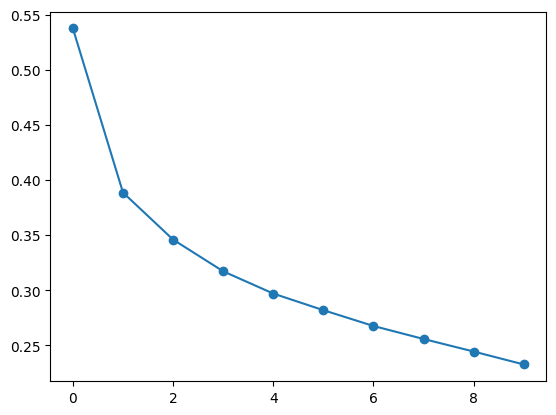

In [55]:
plt.plot(losses4, label="model4 loss", marker='o')
plt.show()

In [56]:
model5 = NN1(nn.SiLU())
opt5 = torch.optim.SGD(model5.parameters(), lr=1e-1)
losses5, train5_acc = train(model5, opt5)
valid5_acc = eval(model5)
print(f"trainAcc: {train5_acc[-1]}, ValidAcc: {valid5_acc}")

Epoch 1/10, Loss: 1.0328071813265483, Accuracy: 60.608333333333334
Epoch 2/10, Loss: 0.4775143075625102, Accuracy: 82.56
Epoch 3/10, Loss: 0.41468191885153455, Accuracy: 84.74666666666667
Epoch 4/10, Loss: 0.3804504793008169, Accuracy: 85.73
Epoch 5/10, Loss: 0.35771291844646136, Accuracy: 86.64666666666666
Epoch 6/10, Loss: 0.3393973347286383, Accuracy: 87.38
Epoch 7/10, Loss: 0.3239103096187115, Accuracy: 87.85333333333334
Epoch 8/10, Loss: 0.31186503544648486, Accuracy: 88.42666666666666
Epoch 9/10, Loss: 0.3029327472150326, Accuracy: 88.76
Epoch 10/10, Loss: 0.29289721951285996, Accuracy: 88.97333333333333
trainAcc: 88.97333333333333, ValidAcc: 86.83


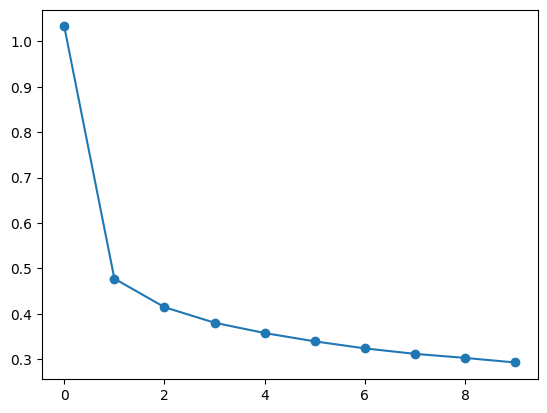

In [57]:
plt.plot(losses5, label="model5 loss", marker='o')
plt.show()

## I played with the optimizer and activation function turns out SGD is really bad with low lr but when i increased lr it did well
## performance of the 2 other optimizers ADAM and RMSprop with GILU or ELU is decent related to only small numbers of epochs, model didnt overfit
## silu with ADAM is doing well